# 07 · Rangos de precio del café (Arábica y Robusta)
**High Garden Coffee**

**Pregunta:** ¿entre qué valores puede moverse el precio del café en los próximos años? 

## Cómo se responde (y con qué cautelas)
| Decisión | Razón |
|---|---|
| Se modela el **precio real** (US$ de 2019/kg), no el nominal | Ver notebook 06: en términos reales el precio *bajó* entre 1990 y 2018 aunque el nominal subió |
| Se pronostica el **promedio anual** a 1-6 años desde diciembre de 2018 | Es la escala en que se toman decisiones comerciales |
| **Solo 3 modelos**, sin parámetros ajustados a mano | Con ~15 orígenes de backtest solapados, ajustar pesos sería sobreajustar |
| Los rangos salen de **errores reales del backtest** y se mide su cobertura fuera de muestra | Un "intervalo del 80%" que no cubre el 80% engaña |
| **Validación con precios reales de 2019-2025**, que no participaron en la elección | Nuestros datos de precios terminan en 2018; hoy esos años ya ocurrieron |

**Modelos:** *ingenuo* (el precio se queda donde está) · *reversión a la media* AR(1) (vuelve hacia su nivel de largo plazo) · *combinación* 50/50.

In [11]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import external_data as E
import price_forecast as P
from utils import *

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.float_format = "{:,.2f}".format
AZUL, GRIS, CORAL, VERDE = "#202850", "#8a94ad", "#E18773", "#00B174"
NOMBRE = P.SERIES

## 1. Datos: precio real mensual 1990-2018

Meses por serie: 348 (1990-01 → 2018-12)
Precio real anual (US$ de 2019/kg): mín / mediana / máx
                       min  median  max
Arábica (Other Milds) 1.93    3.52 6.80
Robusta               0.88    2.10 4.66


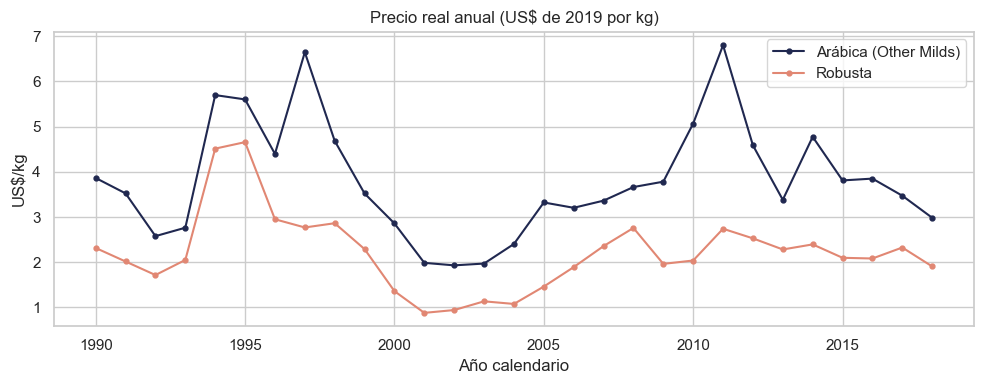

In [12]:
series = P.preparar_series()
realizado = P.cargar_realizado()
anual = pd.DataFrame({n: s.groupby(s.index.year).mean() for n, s in series.items()})
print(f"Meses por serie: {len(series['robustas'])} ({series['robustas'].index.min():%Y-%m} → {series['robustas'].index.max():%Y-%m})")
print("Precio real anual (US$ de 2019/kg): mín / mediana / máx")
print(anual.agg(["min", "median", "max"]).T.rename(index=NOMBRE).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
for n, c in zip(series, (AZUL, CORAL)):
    ax.plot(anual.index, anual[n], marker="o", ms=3.5, color=c, label=NOMBRE[n])
ax.set(title="Precio real anual (US$ de 2019 por kg)", xlabel="Año calendario", ylabel="US$/kg"); ax.legend()
plt.tight_layout(); save_fig("precio_real_historico"); plt.show()

## 2. Backtest: ¿qué tan bien se pronostica a 1-6 años?
Origen móvil: cada diciembre desde 1999 se ajusta el modelo **solo con datos hasta esa fecha** y se compara con lo que pasó. Hay entre 19 orígenes (año 1) y 14 (año 6), y son **muy solapados**: las conclusiones son orientativas.

In [13]:
bt = P.backtest(series)
met = P.metricas(bt)
mdape = met.pivot_table(index=["serie", "modelo"], columns="k", values="mdape")
print("Error porcentual mediano (MdAPE) por horizonte (años):")
display((mdape * 100).round(0).astype(int).astype(str) + "%")
prom = met.groupby("modelo").mdape.mean().sort_values()
print("\nMdAPE promedio (años 1-6, ambas series):", {m: f"{v:.1%}" for m, v in prom.items()})

Error porcentual mediano (MdAPE) por horizonte (años):


k                      1    2    3    4    5    6
serie       modelo                               
other_milds blend     9%  19%  22%  31%  29%  32%
            meanrev  10%  19%  19%  25%  31%  29%
            naive     8%  21%  25%  36%  40%  45%
robustas    blend    11%  19%  22%  19%  31%  31%
            meanrev  11%  17%  22%  20%  30%  35%
            naive    11%  20%  17%  17%  28%  27%


MdAPE promedio (años 1-6, ambas series): {'meanrev': '22.3%', 'blend': '22.9%', 'naive': '24.7%'}


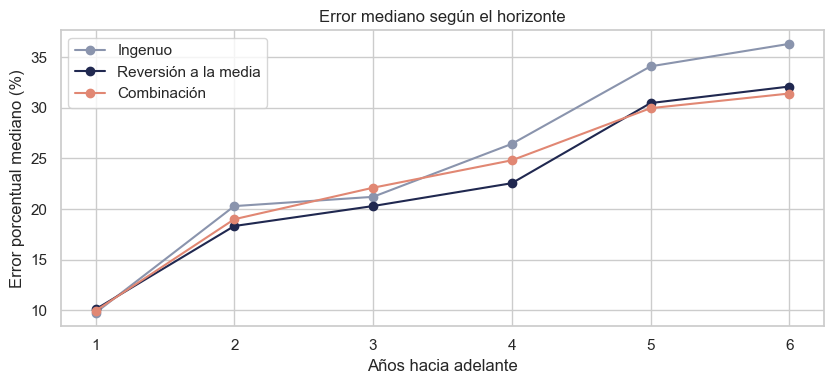

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 4))
for m, c in zip(P.MODELOS, (GRIS, AZUL, CORAL)):
    v = met[met.modelo == m].groupby("k").mdape.mean() * 100
    ax.plot(v.index, v.values, marker="o", color=c, label={"naive": "Ingenuo", "meanrev": "Reversión a la media", "blend": "Combinación"}[m])
ax.set(title="Error mediano según el horizonte", xlabel="Años hacia adelante", ylabel="Error porcentual mediano (%)"); ax.legend()
plt.tight_layout(); save_fig("precio_error_vs_horizonte"); plt.show()

**Lectura.** El error crece de ~10% a un año hasta ~30-40% a cinco o seis. Las diferencias *entre* modelos son pequeñas frente a esa incertidumbre, y con tan pocos orígenes no son estadísticamente concluyentes. Se adopta la **reversión a la media** por su fundamento económico (los precios reales de materias primas revierten porque la oferta responde) y porque ocupa el primer o segundo lugar; no por una victoria clara.

*Se probaron además un promedio móvil de 5 años y una mezcla nivel actual/media histórica con peso fijo. La mezcla parecía mejor, pero su mejora depende del peso elegido y no se sostiene de forma robusta; por eso no se adopta (sería elegir el mejor de varios con muy pocos datos).*

## 3. Intervalos del 80% y su cobertura real
La banda es el pronóstico multiplicado y dividido por `exp(z · RMS del error)` de cada horizonte, agrupando ambas series. Cuantiles empíricos y bandas gaussianas por serie se probaron primero y **subestimaban** la incertidumbre (cubrían 58-72% cuando prometían 80%).

La cobertura se mide con *dejar un origen fuera*: cada punto se evalúa con una banda calibrada **sin él ni los orígenes que se solapan**.

,factor de la banda (×/÷),cobertura efectiva,cobertura prometida
k,,,
1,1.25,84%,80%
2,1.54,81%,80%
3,1.63,79%,80%
4,1.72,75%,80%
5,1.87,67%,80%
6,2.01,62%,80%


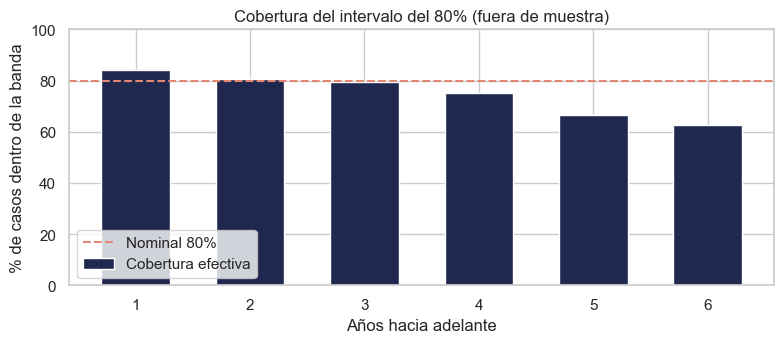

In [15]:
cov = P.cobertura_loo(bt)
c_mr = cov[cov.modelo == "meanrev"]
efectiva = c_mr.groupby("k").apply(lambda d: np.average(d.cobertura, weights=d.n_eval))
cal = P.calibrar_intervalos(bt)
sem = cal[(cal.modelo == "meanrev") & (cal.serie == "robustas")].set_index("k").q_hi
tabla = pd.DataFrame({"factor de la banda (×/÷)": np.exp(sem), "cobertura efectiva": efectiva, "cobertura prometida": 0.80})
tabla_txt = tabla.copy()
tabla_txt["factor de la banda (×/÷)"] = tabla["factor de la banda (×/÷)"].map("{:.2f}".format)
tabla_txt["cobertura efectiva"] = tabla["cobertura efectiva"].map("{:.0%}".format)
tabla_txt["cobertura prometida"] = tabla["cobertura prometida"].map("{:.0%}".format)
display(tabla_txt)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(efectiva.index, efectiva.values * 100, color=AZUL, width=0.6, label="Cobertura efectiva")
ax.axhline(80, color=CORAL, ls="--", label="Nominal 80%")
ax.set(title="Cobertura del intervalo del 80% (fuera de muestra)", xlabel="Años hacia adelante", ylabel="% de casos dentro de la banda", ylim=(0, 100)); ax.legend(loc="lower left")
plt.tight_layout(); save_fig("precio_cobertura"); plt.show()

**Lectura.** Hasta el año 3 la cobertura efectiva es cercana a la prometida (≈80%). **A partir del año 4 se queda corta** (≈75%, 67%, 62%): la banda subestima la incertidumbre en horizontes largos porque los errores incluyen cambios de régimen que 15 orígenes no representan bien. Se reporta tal cual, sin ajustarla hasta que "salga bien".

Las bandas son **muy anchas**: ×/÷ 1.25 a un año, ×/÷ 1.6 a tres y ×/÷ 2.0 a seis. Es una propiedad del mercado (la desviación estándar del cambio anual del precio real es ~27% en ambas series), no un defecto del método.

## 4. Pronóstico desde diciembre de 2018

In [16]:
rangos = P.pronostico_con_rangos(series, bt, origen=2018, modelo="meanrev")
r = rangos.assign(serie=rangos.serie.map(NOMBRE))
display(r.pivot(index="anio", columns="serie", values=["lo", "central", "hi"]).round(2))

lo                       central          \
serie Arábica (Other Milds) Robusta Arábica (Other Milds) Robusta   
anio                                                                
2019                   2.34    1.41                  2.93    1.76   
2020                   1.99    1.16                  3.05    1.78   
2021                   1.93    1.11                  3.15    1.81   
2022                   1.87    1.06                  3.23    1.83   
2023                   1.76    0.99                  3.29    1.84   
2024                   1.66    0.92                  3.34    1.86   

                         hi          
serie Arábica (Other Milds) Robusta  
anio                                 
2019                   3.67    2.20  
2020                   4.69    2.74  
2021                   5.14    2.94  
2022                   5.56    3.15  
2023                   6.14    3.44  
2024                   6.72    3.74

## 5. Validación fuera de muestra con precios reales 2019-2025
Los datos de precios de este proyecto terminan en 2018, pero **hoy los años siguientes ya ocurrieron**. Se comparan con los precios realizados (Banco Mundial y FMI, ver `datos_externos/precios_realizados_2019_2025.csv`), deflactados con el IPC real de cada año. Estos datos **no se usaron para elegir modelo ni calibrar bandas**.

*Empalme:* el promedio 2018 del archivo de la ICO (2.93 y 1.87 US$/kg) coincide con el del Banco Mundial, así que las series son comparables sin ajustes.

In [17]:
val = P.validar_fuera_de_muestra(rangos, realizado)
v = val.assign(serie=val.serie.map(NOMBRE))
tv = v[["serie", "anio", "k", "lo", "central", "hi", "real", "desvio_vs_central", "posicion"]].copy()
for c in ["lo", "central", "hi", "real"]:
    tv[c] = tv[c].map("{:.2f}".format)
tv["desvio_vs_central"] = tv["desvio_vs_central"].map("{:+.0%}".format)
display(tv.reset_index(drop=True))

print(f"Dentro de la banda del 80%: {int(val.dentro.sum())} de {len(val)}")
comp = []
for m in P.MODELOS:
    vm = P.validar_fuera_de_muestra(P.pronostico_con_rangos(series, bt, 2018, m), realizado)
    comp.append({"modelo": m, "dentro de la banda": f"{int(vm.dentro.sum())}/{len(vm)}",
                 "error porcentual mediano": f"{np.median(np.abs(vm.real / vm.central - 1)):.0%}"})
display(pd.DataFrame(comp).set_index("modelo"))

,serie,anio,k,lo,central,hi,real,desvio_vs_central,posicion
0,Arábica (Other Milds),2019,1,2.34,2.93,3.67,2.88,-2%,dentro
1,Arábica (Other Milds),2020,2,1.99,3.05,4.69,3.28,+7%,dentro
2,Arábica (Other Milds),2021,3,1.93,3.15,5.14,4.26,+35%,dentro
3,Arábica (Other Milds),2022,4,1.87,3.23,5.56,4.92,+52%,dentro
4,Arábica (Other Milds),2023,5,1.76,3.29,6.14,3.81,+16%,dentro
5,Arábica (Other Milds),2024,6,1.66,3.34,6.72,4.59,+37%,dentro
6,Robusta,2019,1,1.41,1.76,2.20,1.62,-8%,dentro
7,Robusta,2020,2,1.16,1.78,2.74,1.50,-16%,dentro
8,Robusta,2021,3,1.11,1.81,2.94,1.87,+3%,dentro
9,Robusta,2022,4,1.06,1.83,3.15,2.00,+9%,dentro


Dentro de la banda del 80%: 12 de 12


,dentro de la banda,error porcentual mediano
modelo,,
naive,10/12,21%
meanrev,12/12,16%
blend,11/12,19%


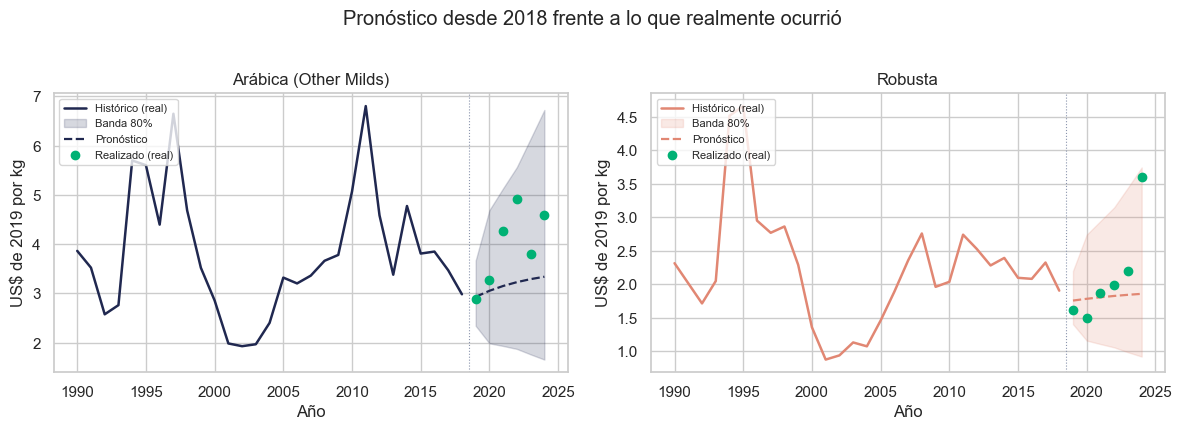

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=False)
for ax, (n, c) in zip(axes, zip(series, (AZUL, CORAL))):
    ax.plot(anual.index, anual[n], color=c, lw=1.8, label="Histórico (real)")
    g = rangos[rangos.serie == n]
    ax.fill_between(g.anio, g.lo, g.hi, color=c, alpha=0.18, label="Banda 80%")
    ax.plot(g.anio, g.central, color=c, ls="--", lw=1.6, label="Pronóstico")
    rr = val[val.serie == n]
    ax.scatter(rr.anio, rr.real, color=VERDE, zorder=5, s=36, label="Realizado (real)")
    ax.axvline(2018.5, color=GRIS, lw=0.8, ls=":")
    ax.set(title=NOMBRE[n], xlabel="Año", ylabel="US$ de 2019 por kg"); ax.legend(fontsize=8, loc="upper left")
plt.suptitle("Pronóstico desde 2018 frente a lo que realmente ocurrió", y=1.02)
plt.tight_layout(); save_fig("precio_pronostico_vs_realizado"); plt.show()

In [19]:
# 2025 sin IPC anual (el BLS no publicó octubre de 2025): solo en términos nominales
n25, n18 = realizado.set_index("year").loc[2025], anual.copy()
nom18 = {n: float(P.promedio_anual(E.construir_precios()[0].set_index("fecha")[n], 2018)) for n in series}
print("2025 en dólares nominales (US$/kg) frente al promedio nominal de 2018:")
for n in series:
    print(f"  {NOMBRE[n]:22s} 2018: {nom18[n]:.2f} → 2025: {n25[f'{n}_nominal']:.2f}  ({n25[f'{n}_nominal'] / nom18[n] - 1:+.0%})")

2025 en dólares nominales (US$/kg) frente al promedio nominal de 2018:
  Arábica (Other Milds)  2018: 2.93 → 2025: 8.45  (+188%)
  Robusta                2018: 1.87 → 2025: 4.86  (+159%)


**Lectura honesta.**
- Con datos hasta 2018, **el modelo no anticipó** el alza de 2021-2024: el valor central quedó **por debajo** del real desde el tercer año (Arábica hasta +52% por encima del central en 2022; Robusta +94% en 2024).
- Aun así, **los 12 precios reales cayeron dentro de la banda del 80%**, pero eso se logra porque la banda es muy ancha: el Robusta de 2024 quedó prácticamente en el borde superior (posición 0.97 dentro de la banda) y el Arábica de 2022 en 0.89. Doce observaciones correlacionadas no prueban que la banda esté bien calibrada: la medición fuera de muestra del punto 3 es más confiable (cobertura efectiva 62-84%).
- La reversión a la media mejora al ingenuo (error mediano 16% frente a 21%), pero **ningún modelo estadístico de precio habría previsto un régimen como el de 2021-2025** (2025 en nominal: Arábica ≈ 8.4 US$/kg, casi el triple de 2018).

## 6. Qué significa para el negocio
1. **Usar rangos, no un precio esperado.** A tres años el precio puede estar 1.6 veces por encima o por debajo del central; a seis, 2 veces.
2. **El precio no reemplaza al consumo como variable de decisión de mercado.** En una prueba exploratoria previa el precio no explicó el crecimiento del consumo del año siguiente (correlación ≈ 0.03 con el precio al productor y ≈ 0.10 con el minorista). Por eso el pronóstico de consumo (notebook 02) **no usa precios**. Los rangos de precio sirven para **escenarios de margen e ingresos**, no para corregir demanda.
3. **Probar la estrategia bajo el escenario alto y el bajo**, no solo en el central: el riesgo asimétrico está en el alza reciente, que el modelo no captó.
4. **Actualizar con datos recientes.** La función acepta cualquier serie mensual: con el Pink Sheet del Banco Mundial (mensual, hasta 2026) el mismo código produce rangos desde hoy. Es la mejora de mayor valor.

## 7. Guardar

In [20]:
OUT.mkdir(exist_ok=True)
bt.to_parquet(OUT / "price_backtest.parquet", index=False)
met.to_csv(OUT / "price_metrics.csv", index=False)
cov.to_csv(OUT / "price_coverage.csv", index=False)
rangos.to_parquet(OUT / "price_forecast_2019_2024.parquet", index=False)
val.to_parquet(OUT / "price_validation.parquet", index=False)
for f in ("price_backtest.parquet", "price_forecast_2019_2024.parquet", "price_validation.parquet", "price_metrics.csv", "price_coverage.csv"):
    print("✓", f)

import test_price_forecast as T
pruebas = T.run_all(verbose=False)
print("\nPruebas:", pruebas.resultado.value_counts().to_dict())

✓ price_backtest.parquet
✓ price_forecast_2019_2024.parquet
✓ price_validation.parquet
✓ price_metrics.csv
✓ price_coverage.csv

Pruebas: {'OK': 13}


## 8. Límites
- **Pocos datos:** 29 años de precios; 14-19 orígenes de backtest solapados. Las diferencias entre modelos no son concluyentes.
- **Cobertura corta a 4-6 años** (75%, 67%, 62% frente a 80% prometido).
- **Régimen 2021-2025** fuera de lo observado en 1990-2018; el modelo lo subestima.
- **Precios de referencia globales**, no precios de venta de High Garden ni por país.
- **IPC de EE. UU.** como deflactor; 2025 solo en nominal.
- **Empalme de fuentes:** 2019-2020 (Banco Mundial, oct-2021) y 2021-2025 (FMI vía FRED) pueden diferir levemente por revisiones.